In [18]:
# --- Base imports ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect
import html
from IPython.display import display, HTML

# --- Path setup ---
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Needed because ML modules use sibling imports like: from ML_level_utilities import ...
ORIGINAL_ML_DIR = PROJECT_ROOT / "Legendre_Polynomials" / "Multi_Level" / "Original_Programs"
if str(ORIGINAL_ML_DIR) not in sys.path:
    sys.path.append(str(ORIGINAL_ML_DIR))

# Optional: if you want to reuse SL surface plotter in this OT notebook
SINGLE_LEVEL_DIR = PROJECT_ROOT / "Legendre_Polynomials" / "Single_Level"
if str(SINGLE_LEVEL_DIR) not in sys.path:
    sys.path.append(str(SINGLE_LEVEL_DIR))

# --- Optional (recommended) for syntax highlighting ---
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

_PYGMENTS_CSS_LOADED = False

def show_full_function(func, name=None):
    global _PYGMENTS_CSS_LOADED
    
    name = name or func.__name__
    source = inspect.getsource(func)

    formatter = HtmlFormatter(style="friendly", noclasses=False)
    highlighted = highlight(source, PythonLexer(), formatter)

    if not _PYGMENTS_CSS_LOADED:
        css = formatter.get_style_defs('.highlight')
        display(HTML(f"<style>{css}</style>"))
        _PYGMENTS_CSS_LOADED = True

    html_block = f"""
    <details>
      <summary><strong>View full function: {html.escape(name)}</strong></summary>
      {highlighted}
    </details>
    """
    display(HTML(html_block))


# --- Core OT-ML imports ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_optimal_transport import (
    GaussianBrenierMap,
    identity_map,
    logpaths_maps,
    apply_maps,
    validate_maps,
    mlmc_l_OT,
    make_c_OT,
)

# --- ML utilities reused by OT workflow ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_level_utilities import (
    tot_degree_poly,
    make_b_bar,
    normaleq_components_ML,
    fit_local_vol,
    GBM_paths,
)

from Legendre_Polynomials.Multi_Level.Original_Programs.ML_telescoping_sum import (
    scalings_l0,
    mlmc_l,   # useful for standard-vs-OT comparison
    make_c,
)

# --- Validation ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_weak_error_analysis import (
    compute_weak_error_ML,
    plot_weak_error_convergence,
)

# --- Optional visualization helper (reuse from Single-Level) ---
from Legendre_Polynomials.Single_Level.SL_surface_visualisation import (
    plot_local_volatility,
)

<h1 style="text-align: center;">Multi-Level Optimal Transport Map Markovian Projection with Legendre Polynomial Regression</h1>

## Black-Scholes Correlated Model:
We consider a $d$-dimensional correlated Black--Scholes model
\begin{align}
dX(t)&=a(t,X(t))\,dt+b(t,X(t))\,dW(t),
\qquad 0\le t\le T,
\qquad X(t)\in\mathbb{R}^d,\\
X(0)&=x_0.
\end{align}
where
- $W(t)$ is a $k$-dim. Brownian motion.
- $a(t,x)=r\,x,\qquad r=0.05.$  
- $b(t,x)\in\mathbb{R}^{d\times k}.$  
- $(b_{\mathrm{BS}}(t,x))_{ij}=x_i\,\Sigma_{ij}.$

### Example ($d=3, k=3$)

Let $x=(x_1,x_2,x_3)^\top$ and $\sigma=(\sigma_1,\sigma_2,\sigma_3)^\top$. Assume the correlated Black–Scholes diffusion is defined by
$$
b_{\mathrm{BS}}(t,x)=\mathrm{diag}(x)\,\mathrm{diag}(\sigma)\,G, \quad \text{equivalently}\;\;\bigl(b_{\mathrm{BS}}(t,x)\bigr)_{ij}=\sigma_i x_i\,G_{ij}
$$
where,
$$
\Sigma_{ij}=\sigma_i\,G_{ij}, \qquad 
GG^\top=
\begin{pmatrix}
1 & 0.8 & 0.3\\
0.8 & 1 & 0.1\\
0.3 & 0.1 & 1
\end{pmatrix},
\qquad
\sigma=(0.2,\ 0.15,\ 0.1)^\top.
$$
Each component satisfies
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\sum_{j=1}^{k}G_{ij}\,dW_j(t),
\qquad i=1,\dots,d.
$$
Thus, even if the Brownian motions $W_1,\dots,W_k$ are independent, the assets are correlated through the matrix $G$.

<details>
<summary><strong>Distribution of $X(t)$</strong></summary>
    In our Black--Scholes setting, we define
$$
\Sigma := \operatorname{diag}(\sigma)\,G \in \mathbb{R}^{d\times d},
\qquad
GG^\top = \rho,
$$
and the asset process $X(t) = (X_1(t),\dots,X_d(t))^\top$ satisfies
$$
dX(t) = r\,X(t)\,dt + \operatorname{diag}(X(t))\,\Sigma\,dW(t),
\qquad
X(0)=x_0,
$$
where $W$ is a standard $d$-dimensional Brownian motion.

Now define the log-process
$$
Y(t) := \log X(t)
=
\bigl(\log X_1(t),\dots,\log X_d(t)\bigr)^\top.
$$

Applying It\^o's formula componentwise, for each $i=1,\dots,d$ we obtain
$$
dY_i(t)
=
\left(
r-\frac12\sum_{j=1}^d \Sigma_{ij}^2
\right)dt
+
\sum_{j=1}^d \Sigma_{ij}\,dW_j(t).
$$

In vector form, this reads
$$
dY(t)
=
\left(
r\mathbf{1}-\frac12\,\operatorname{diag}(\Sigma\Sigma^\top)
\right)dt
+
\Sigma\,dW(t).
$$

Hence, for every fixed $t\geq 0$, the random vector $\log X(t)$ is Gaussian:
$$
\log X(t)\sim \mathcal{N}\bigl(m(t),C(t)\bigr),
$$
with mean and covariance given by
$$
m(t)
=
\log x_0
+
\left(
r\mathbf{1}-\frac12\,\operatorname{diag}(\Sigma\Sigma^\top)
\right)t,
\qquad
C(t)=t\,\Sigma\Sigma^\top.
$$

Since in our example
$$
\Sigma=\operatorname{diag}(\sigma)\,G
\qquad\text{and}\qquad
GG^\top=\rho,
$$
we obtain
$$
\Sigma\Sigma^\top
=
\operatorname{diag}(\sigma)\,\rho\,\operatorname{diag}(\sigma).
$$

Moreover, because $\rho_{ii}=1$ for all $i=1,\dots,d$, we have
$$
\operatorname{diag}(\Sigma\Sigma^\top)
=
(\sigma_1^2,\dots,\sigma_d^2)^\top.
$$

Therefore,
$$
\log X(t)
\sim
\mathcal{N}
\left(
\log x_0+
\begin{pmatrix}
r-\frac12\sigma_1^2\\
\vdots\\
r-\frac12\sigma_d^2
\end{pmatrix}t,
\;
t\,\operatorname{diag}(\sigma)\,\rho\,\operatorname{diag}(\sigma)
\right).
$$
</details>



## Markovian Projection
Let $S(t)=P_1 X(t)$, with $P_1\in\mathbb{R}^{1\times d}$ and $X(t)\in\mathbb{R}^{d\times 1}$. Define the Markovian surrogate $\bar S^{(x_0)}(t)$ by
$$
\left\{
\begin{aligned}
d\bar S^{(x_0)}(t) &= \bar a^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,dt
+ \bar b^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,d\bar W(t), \qquad t\in[0,T],\\
\bar S^{(x_0)}(0) &= P_1 x_0.
\end{aligned}
\right.
$$

The drift and diffusion coefficients are given by conditional expectations:
$$
\bar a^{(x_0)}(t,s)
=\mathbb{E}\!\left[\,P_1 a\!\bigl(t,X(t)\bigr)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
=\mathbb{E}\!\left[\,r\,P_1 X(t)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
= r\,s,
$$
and
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=\mathbb{E}\!\left[\,P_1 b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P_1^\top\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right].
$$
For $P_1=\frac{1}{d}(1,\ldots,1)$ and $C=GG^\top$, this becomes
$$
\bigl(\bar b^{x_0}(t,s)\bigr)^2
=
\mathbb{E}\!\left[
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i(t)\,X_j(t)\,C_{ij}
\ \middle|\ P_1 X(t)=s,\ X(0)=x_0
\right],
$$

## $L^2$ Regression Problem

We approximate $\big(\bar b^{x_0}\big)^2(\cdot,\cdot)$ by solving the time-integrated $L^2$ problem
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\int_{0}^{T}
\mathbb{E}\!\left[
\left(
P\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P^\top
- h\!\bigl(t,PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right]dt.
$$

For example, one may choose a parametric class
$$
V=\{\,h:\ h(t,x)=c_0+c_1 t+c_2 x\,\}.
$$
Discretizing time with a grid $0=t_0<t_1<\cdots<t_N=T$, an empirical Monte Carlo objective is
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\sum_{m=1}^{M}\ \frac{1}{N}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,C_{ij}
- h\!\bigl(t_n,PX^{(m)}(t_n)\bigr)
\right)^2.
$$

**Ansatz.** We approximate the squared projected diffusion by a finite expansion
$$
\tilde b^2(t,s)\approx \sum_{p=1}^{P} c_p\,\psi_p(t,s).
$$

## Legendre Polynomials
Legendre polynomials $\{P_n(x)\}_{n\ge 0}$ are orthogonal on $[-1,1]$:
$$
\int_{-1}^{1} P_m(x)\,P_n(x)\,dx
=
\frac{2}{2n+1}\,\delta_{mn}.
$$

The first few polynomials are:
- $P_0(x)=1$,
- $P_1(x)=x$,
- $P_2(x)=\frac{1}{2}\,(3x^2-1)$,
- $P_3(x)=\frac{1}{2}\,(5x^3-3x)$.

### Orthonormalization
Define the orthonormalized Legendre polynomials by
$$
\tilde P_n(x):=\sqrt{\frac{2n+1}{2}}\,P_n(x).
$$
Then
$$
\int_{-1}^{1}\tilde P_m(x)\,\tilde P_n(x)\,dx=\delta_{mn}.
$$

## Scaling of time and basket value

Because Legendre polynomials are naturally defined on $[-1,1]$, both variables are scaled to that interval.

Time is mapped by
$$
\tau(t)=\frac{2t}{T}-1.
$$

The basket variable is mapped by
$$
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
$$

The bounds $s_{\min}$ and $s_{\max}$ are obtained from a pilot simulation, using empirical lower and upper percentiles of the basket distribution. This gives a practical domain on which the Legendre approximation is fitted.

### Basis Functions
We define bivariate basis functions using orthonormal Legendre polynomials on $[-1,1]$:
$$
\psi_{(i_1,i_2)}(t,s)
=
\tilde P_{i_1}\!\bigl(\tau(t)\bigr)\,\tilde P_{i_2}\!\bigl(\xi(s)\bigr),
\qquad p=(i_1,i_2)\in\Lambda.
$$

We use a **total-degree** index set
$$
\Lambda=\{(i_1,i_2)\in\mathbb{N}_0^2:\ i_1+i_2\le d_{\max}\}.
$$

**Examples.**
- $d_{\max}=0$: $(i_1,i_2)=(0,0)$ $\Rightarrow$ $1$ basis function (constant).
- $d_{\max}=1$: $(0,0),(0,1),(1,0)$ $\Rightarrow$ $3$ basis functions.
- $d_{\max}=2$: $(0,0),(0,1),(0,2),(1,0),(2,0),(1,1)$ $\Rightarrow$ $6$ basis functions.

The approximation of the projected variance is therefore
$$
\tilde b^2(t,s)
=
\sum_{(i,j)\in\Lambda}
c_{ij}\,
\widetilde P_i\!\bigl(\tau(t)\bigr)\,
\widetilde P_j\!\bigl(\xi(s)\bigr).
$$

Finally, the projected local volatility is obtained by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$
<h1 style="text-align: center;">$L^2$ Projection SDES</h1>
Recall:

$$
\big(\bar b^{x_0}\big)^2 \approx \arg\min_{h\in V}\ \frac{1}{M}\sum_m \frac{1}{N}\sum_n
\left(
P_1^{T} b(t_n,X^m(t_n))\,b(t_n,X^m(t_n))^{T}P_1
-
h\bigl(t_n,P_1 X^m(t_n)\bigr)
\right)^2
$$

where $X^m$ are independent realizations of $X$. Denote

$$
g := P_1^{T} b(t,X(t))\,b(t,X(t))^{T}P_1.
$$

$$
S_L(f) := \Pi_{V_L} g_0(X_0) + \sum_{\ell=1}^{L} \Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)
$$

where

$$
\Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)
=
\arg\min_{v\in V_{L-\ell}}
\left\|
\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)-v(\cdot)
\right\|.
$$

Compute the projection of correction $\Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)$ by 
    \begin{align}
\arg\min_{h\in V}
\frac{1}{M_\ell}&\sum_{m=1}^{M_\ell}\frac{1}{N_{\ell-1}}\sum_{n=1}^{\mathbf{{\color{green}{N_{\ell-1}}}}}
\Biggl(
{\color{blue}{\Bigl[
P^\top b\!\bigl(t_n,X_\ell^m(t_n^{\ell-1})\bigr)\,
b\!\bigl(t_n,X_\ell^m(t_n^{\ell-1})\bigr)^\top P
\notag}}\\
&
-
{\color{blue}{P^\top b\!\bigl(t_n,X_{\ell-1}^m(t_n^{\ell-1})\bigr)\,
b\!\bigl(t_n,X_{\ell-1}^m(t_n^{\ell-1})\bigr)^\top P
\Bigr]}}
-
{\color{red}{h\!\bigl(t_n^{\ell-1},PX_\ell^m(t_n^{\ell-1})\bigr)}}
\Biggr)^2
\end{align}
\begin{equation}
    {\color{red}{D \in \mathbb{R}^{M_{\ell}N_{\ell-1}\times |\Lambda|}}}, {\color{blue}{\Psi \in \mathbb{R}^{M_{\ell}N_{\ell-1}}}}, c_{\ell}\in \mathbb{R}^{|\Lambda_{L-\ell}|}
\end{equation}
\begin{equation}
    M_{\ell}=C\times \text{dim}(V_{L-\ell})^2, \quad V_{L-\ell}
=
\operatorname{span}\Bigl\{
\widetilde P_i(\tau(t))\widetilde P_j(\xi(s))
:\ i+j\le L-\ell
\Bigr\}.
\end{equation}
 The estimated coefficient is
\begin{equation}
   (\bar{b}^{x_0})^2(t,s)\approx \sum_{p\in \Lambda_L}c_p \psi(t,s), \quad  c = \{c_p\}_{p\in \Lambda_L}=\sum_{\ell=0}^Lc_{\ell}
\end{equation}
For $t_n^{\ell-1}$ consider 
\begin{equation}
    \mu_{\ell,n}=\mathcal{L}(X_{\ell}(t_n^{\ell-1})),\quad \mu_{\ell-1,n}=\mathcal{L}(X_{\ell-1}(t_n^{\ell-1}))
\end{equation}
Assume that there exists a map $T_{\ell,\ell-1,n}:\mathbb{R}^d\to \mathbb{R}^d$ such that 
\begin{equation}
    \hat{X}^{m}_{\ell-1}(t_n^{\ell-1})= T_{\ell,\ell-1,n}(X_{\ell}^m(t_n^{\ell-1}))\quad \text{and}\quad (T_{\ell,\ell-1})_{\#\mu_{\ell,n}}=\mu_{\ell-1,n}
\end{equation}
Then the projection of the correction at level $\ell$ would be on the fine paths $X_{\ell}$, namely
\begin{equation}
    g(X_{\ell}^m(t_n^{\ell-1}))-g(T_{\ell,\ell-1,n}(X_{\ell}^m(t_n^{\ell-1}))
\end{equation}

We know that at the coarse time nodes $t_n^{\ell-1}$,
$$
\log X\left(t_n^{\ell-1}\right)
\sim
\mathcal{N}\left(m_n,C_n\right),
$$
where
$$
m_n
=
\log x_0+
\left(
r\mathbf{1}-\frac12
\begin{pmatrix}
\sigma_1^2\\
\vdots\\
\sigma_d^2
\end{pmatrix}
\right)t_n^{\ell-1},
\qquad
C_n
=
t_n^{\ell-1}\operatorname{diag}(\sigma)\,\rho\,\operatorname{diag}(\sigma).
$$

### Brenier map between Gaussian laws

Let $\mu_f,\mu_c \in \mathbb{R}^d$ and $C_f,C_c \in \mathbb{R}^{d\times d}$ be the mean vectors and covariance matrices of two Gaussian laws
$$
\mathcal{N}(\mu_f,C_f)
\qquad\text{and}\qquad
\mathcal{N}(\mu_c,C_c).
$$

The Brenier map transporting $\mathcal{N}(\mu_f,C_f)$ to $\mathcal{N}(\mu_c,C_c)$ for the quadratic cost is the affine map
$$
T(x)=\mu_c + A(x-\mu_f),
$$
where
$$
A
=
C_f^{-1/2}
\left(
C_f^{1/2} C_c C_f^{1/2}
\right)^{1/2}
C_f^{-1/2}.
$$

This map satisfies
$$
T_\#\mathcal{N}(\mu_f,C_f)=\mathcal{N}(\mu_c,C_c).
$$

In our setting, at each coarse time node $t_n^{\ell-1}$, we approximate the log-space marginals of the reduced fine state and the coarse state by Gaussian laws,
$$
\log X_\ell(t_n^{\ell-1}) \approx \mathcal{N}(\mu_{\ell,n}^{f},C_{\ell,n}^{f}),
\qquad
\log X_{\ell-1}(t_n^{\ell-1}) \approx \mathcal{N}(\mu_{\ell,n}^{c},C_{\ell,n}^{c}),
$$
and define the corresponding Gaussian Brenier map by
$$
T_{\ell,\ell-1,n}(x)
=
\mu_{\ell,n}^{c}
+
A_{\ell,n}\bigl(x-\mu_{\ell,n}^{f}\bigr),
$$
with
$$
A_{\ell,n}
=
\bigl(C_{\ell,n}^{f}\bigr)^{-1/2}
\left(
\bigl(C_{\ell,n}^{f}\bigr)^{1/2}
C_{\ell,n}^{c}
\bigl(C_{\ell,n}^{f}\bigr)^{1/2}
\right)^{1/2}
\bigl(C_{\ell,n}^{f}\bigr)^{-1/2}.
$$

Thus, for each sample $m$, the transported coarse-state approximation is defined by
$$
\widehat X_{\ell-1}^m(t_n^{\ell-1})
=
\exp\left(
T_{\ell,\ell-1,n}\bigl(\log X_\ell^m(t_n^{\ell-1})\bigr)
\right).
$$

In particular, the map is constructed in log-space using empirical mean vectors and covariance matrices estimated from simulated fine and coarse samples at the common coarse time nodes.

<h1 style="text-align: center;">Implementation</h1>

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 1: Model setup, ML hierarchy setup, and pilot scaling domain
</h4>
<details>
In this first step, we initialize the market parameters and the multi-level hierarchy, then compute the basket scaling interval used by the Legendre basis.

We keep the same correlated Black--Scholes model:
\begin{equation}
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\sum_{j=1}^{d}G_{ij}\,dW_j(t),
\qquad i=1,\dots,d.
\end{equation}

The OT-ML method will later couple fine and coarse levels, but before that we need:
- a coarsest timestep $h_0$,
- a maximum level/degree $L=\texttt{max\_deg}$,
- and basket domain bounds $[s_{\min},s_{\max}]$.

The level timesteps are
\begin{equation}
h_\ell = h_0\,2^{-\ell},\qquad \ell=0,\dots,L.
\end{equation}

Legendre basis evaluation requires scaling the basket variable to $[-1,1]$:
\begin{equation}
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
\end{equation}

So we estimate $s_{\min},s_{\max}$ with a pilot run at the finest level.

#### Function used: `scalings_l0`

**Syntax**
```python
s_min0, s_max0, basket0 = scalings_l0(
    x0, T, h0, r, cov_mat, vol, max_deg, P1,
    M_0=10000, return_basket=True
)
```

**What it does**
- Runs pilot simulation at the finest timestep:
  \begin{equation}
  h_{\text{fine}}=h_0\,2^{-L},\qquad L=\texttt{max\_deg}.
  \end{equation}
- Computes lower/upper basket percentiles to define the regression domain.
- Returns:
  - `s_min0`, `s_max0`: domain bounds,
  - `basket0`: pilot basket paths (useful later for plotting).

This step does not yet build OT maps; it prepares all global inputs needed for OT map construction and OT level corrections.

</details>

In [9]:
show_full_function(GBM_paths)

In [6]:
show_full_function(scalings_l0)

In [3]:
# Step 1: model + hierarchy + pilot domain

# Basket/model parameters
d = 3
P1 = np.ones(d) / d

r = 0.05
x0 = np.linspace(225, 275, num=d)[:, np.newaxis]
vol = np.array([0.2, 0.15, 0.1])
cov_mat = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.1],
    [0.3, 0.1, 1.0]
])

# Time and multi-level hierarchy
T = 1.0
h0 = 0.125
max_deg = 3   # L = max_deg levels for this setup

# Pilot run for basket scaling domain
s_min0, s_max0, basket0 = scalings_l0(
    x0=x0,
    T=T,
    h0=h0,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    M_0=10000,
    return_basket=True
)

print("\n--- Step 1 summary ---")
print("d =", d)
print("P1 =", P1)
print("T =", T)
print("h0 =", h0)
print("max_deg (L) =", max_deg)
print("number of levels =", max_deg + 1)
print("finest dt =", h0 * 2**(-max_deg))
print("s_min0 =", s_min0)
print("s_max0 =", s_max0)
print("basket0 shape =", basket0.shape)


--- Step 1 summary ---
d = 3
P1 = [0.33333333 0.33333333 0.33333333]
T = 1.0
h0 = 0.125
max_deg (L) = 3
number of levels = 4
finest dt = 0.015625
s_min0 = 180.68243919878222
s_max0 = 379.3759492857599
basket0 shape = (10000, 64)


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 2: Build Gaussian-Brenier maps between fine and coarse levels
</h4>
<details>
Now we construct the optimal transport maps that couple fine and coarse levels.

For a fixed level $\ell\ge 1$, we generate:
- fine paths with timestep $h_\ell$,
- coarse paths with timestep $h_{\ell-1}=2h_\ell$,
- fine paths reduced at coarse timestamps.

Then, at each coarse time $t_n^{\ell-1}$, we move to log-space:
\begin{equation}
Y_\ell=\log X_\ell,\qquad Y_{\ell-1}=\log X_{\ell-1},
\end{equation}
estimate empirical Gaussian moments, and build the Brenier map
\begin{equation}
T_{\ell,\ell-1,n}^{\log}(y)=\mu_{\ell-1,n}^{\log}
+
A_{\ell,n}\big(y-\mu_{\ell,n}^{\log}\big).
\end{equation}

So this step gives the map sequence
\begin{equation}
\{T_{\ell,\ell-1,n}\}_{n=0}^{N_{\ell-1}-1},
\end{equation}
which is the core OT coupling object used in later regression corrections.

#### Function used: `logpaths_maps`

**Syntax**
```python
maps, paths_f_red, paths_c = logpaths_maps(
    x0, T, h0, l, r, cov_mat, vol, max_deg,
    return_redpathsf=True,
    return_pathsc=True,
    C=80
)
```

**What it does**
- Generates coupled fine/coarse paths at level `l`.
- Reduces fine paths to coarse time indices.
- Computes empirical means/covariances in log-space at each coarse time.
- Constructs one Gaussian-Brenier map per time index.
- Returns:
  - `maps`: list of transport maps,
  - `paths_f_red`: fine paths sampled at coarse timestamps,
  - `paths_c`: coarse paths.

#### Function used: `validate_maps` (optional but recommended)

**Syntax**
```python
ok = validate_maps(logpaths_f, logpaths_c, maps, tol_mean=1e-2, tol_var=1e-2)
```

**What it does**
- Checks whether transported fine samples match coarse moments (mean/covariance).
- Gives a practical diagnostic of map quality before using OT correction in regression.

This validation is not strictly required to run OT-ML, but it is very useful for understanding whether coupling is behaving as expected.

</details>

In [11]:
show_full_function(logpaths_maps)

In [10]:
# Step 2: build OT maps at one representative level

l_test = 1  # must be >= 1 for OT mapping

maps, paths_f_red, paths_c = logpaths_maps(
    x0=x0,
    T=T,
    h0=h0,
    l=l_test,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    return_redpathsf=True,
    return_pathsc=True,
    C=80
)

print("\n--- Step 2 summary ---")
print("level l_test =", l_test)
print("number of maps =", len(maps))
print("paths_f_red shape =", paths_f_red.shape)
print("paths_c shape =", paths_c.shape)

# Optional map-quality check in log-space
logpaths_f = np.log(paths_f_red)
logpaths_c = np.log(paths_c)

ok = validate_maps(
    logpaths_f=logpaths_f,
    logpaths_c=logpaths_c,
    maps=maps,
    tol_mean=1e-2,
    tol_var=1e-2,
    verbose=True
)

print("map validation passed =", ok)


--- Step 2 summary ---
level l_test = 1
number of maps = 8
paths_f_red shape = (2880, 8, 3)
paths_c shape = (2880, 8, 3)
Timestep 0: mean_diff=0.000e+00, cov_diff=0.000e+00, pass=True
Timestep 1: mean_diff=2.309e-14, cov_diff=2.591e-17, pass=True
Timestep 2: mean_diff=1.155e-14, cov_diff=5.535e-17, pass=True
Timestep 3: mean_diff=7.105e-15, cov_diff=1.907e-17, pass=True
Timestep 4: mean_diff=1.066e-14, cov_diff=4.348e-17, pass=True
Timestep 5: mean_diff=1.688e-14, cov_diff=4.090e-17, pass=True
Timestep 6: mean_diff=2.132e-14, cov_diff=9.493e-17, pass=True
Timestep 7: mean_diff=2.132e-14, cov_diff=8.278e-17, pass=True
map validation passed = True


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 3: Apply OT maps and compute one OT level correction
</h4>
<details>

After constructing the map sequence \(\{T_{\ell,\ell-1,n}\}\), the next step is to apply these maps to the fine paths (at coarse timestamps) to obtain estimated coarse paths:
\begin{equation}
\widehat X_{\ell-1}^m(t_n^{\ell-1})
=
T_{\ell,\ell-1,n}\!\big(X_\ell^m(t_n^{\ell-1})\big).
\end{equation}

Then, instead of standard fine-coarse correction
\begin{equation}
g(X_\ell)-g(X_{\ell-1}),
\end{equation}
we use the OT-corrected difference
\begin{equation}
g(X_\ell)-g(\widehat X_{\ell-1}),
\end{equation}
where
\begin{equation}
g(x)=P^\top b(t,x)b(t,x)^\top P.
\end{equation}

This is exactly the target used to build the regression system for the level correction.

#### Function used: `apply_maps`

**Syntax**
```python
est_paths_c = apply_maps(paths_f_red, maps, input_logpaths=False)
```

**What it does**
- Applies time-indexed OT maps to the reduced fine paths.
- Returns estimated coarse paths \(\widehat X_{\ell-1}\) in state space.

#### Function used: `normaleq_components_ML`

**Syntax**
```python
D_ot, psi_ot = normaleq_components_ML(
    paths_f_red, est_paths_c, P1, pairs_l, cov_mat, vol,
    s_min0, s_max0, T, pathsf_are_reduced=True
)
```

**What it does**
- Builds the Legendre design matrix \(D\) on coarse timestamps.
- Builds target vector \(\psi\) as correction difference between fine and transported-coarse variances.
- Uses `pathsf_are_reduced=True` to indicate fine paths are already on coarse time grid.

#### Function used: `fit_local_vol`

**Syntax**
```python
c_l_ot = fit_local_vol(D_ot, psi_ot)
```

**What it does**
- Solves the least-squares problem for this level correction:
\begin{equation}
\min_c \|D_{ot}c-\psi_{ot}\|_2^2.
\end{equation}

So this step gives one OT level correction coefficient vector \(c_\ell^{OT}\), which will later be aggregated across levels.

</details>

In [14]:
show_full_function(apply_maps)

In [13]:
# Step 3: apply OT maps and compute one OT level correction (manual pipeline)

# 1) Apply OT maps to reduced fine paths -> estimated coarse paths
est_paths_c = apply_maps(paths_f_red, maps, input_logpaths=False)

# 2) Level-dependent basis for this l_test
deg_l = max_deg - l_test
pairs_l = tot_degree_poly(deg_l)

# 3) Build regression system with OT-corrected coarse paths
D_ot, psi_ot = normaleq_components_ML(
    paths_f=paths_f_red,
    paths_c=est_paths_c,
    P1=P1,
    pairs=pairs_l,
    cov_mat=cov_mat,
    vol=vol,
    s_min=s_min0,
    s_max=s_max0,
    T=T,
    pathsf_are_reduced=True
)

# 4) Fit level correction coefficients
c_l_ot = fit_local_vol(D_ot, psi_ot)

print("\n--- Step 3 summary ---")
print("level =", l_test)
print("deg_l =", deg_l)
print("number of basis functions =", len(pairs_l))
print("D_ot shape =", D_ot.shape)
print("psi_ot shape =", psi_ot.shape)
print("c_l_ot shape =", c_l_ot.shape)
print("first c_l_ot coefficients =", c_l_ot[:8])


--- Step 3 summary ---
level = 1
deg_l = 2
number of basis functions = 6
D_ot shape = (23040, 6)
psi_ot shape = (23040, 1)
c_l_ot shape = (6,)
first c_l_ot coefficients = [ 1.40533288  1.57161136  0.61854816  0.26286033  0.51931145 -0.05088739]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Step 4: Aggregate OT corrections across levels and build the final projected volatility
</h4>
<details>
After understanding one level correction, we now construct the final OT multi-level coefficient vector.

The aggregation is hybrid:
- level \(0\): standard ML correction (no coarser level to transport to),
- levels \(\ell\ge 1\): OT-corrected level corrections.

So the final coefficient vector is
\begin{equation}
c^{OT}
=
c_0+\sum_{\ell=1}^{L} c_\ell^{OT}.
\end{equation}

#### Function used: `make_c_OT`

**Syntax**
```python
c_ot = make_c_OT(x0, T, h0, r, cov_mat, vol, max_deg, P1, s_min0, s_max0, C=80)
```

**What it does**
- Computes the level-0 contribution with standard `mlmc_l(...)`.
- Computes levels \(1,\dots,L\) with OT via `mlmc_l_OT(...)`.
- Returns the aggregated coefficient vector in the max-level basis.

This gives the final coefficient representation of the OT-ML approximation.

#### Function used: `tot_degree_poly`

**Syntax**
```python
pairs_max = tot_degree_poly(max_deg)
```

**What it does**
- Builds the final basis index set \(\Lambda_L\) used to interpret `c_ot`.

#### Function used: `make_b_bar`

**Syntax**
```python
b_bar_ot = make_b_bar(c_ot, pairs_max, s_min0, s_max0, T, max_deg)
```

**What it does**
- Converts the aggregated coefficient vector into the callable local volatility function:
\begin{equation}
\bar b_{OT}(t,s)=\sqrt{\tilde b_{OT}^2(t,s)}.
\end{equation}

So this step turns level-wise OT corrections into the final projected diffusion coefficient used in pricing validation.

### Optional comparison object

For fair method comparison, we can also compute the standard ML version:
\begin{equation}
c^{ML}=\sum_{\ell=0}^{L} c_\ell,\qquad
\bar b_{ML}(t,s)=\sqrt{\tilde b_{ML}^2(t,s)}.
\end{equation}
This allows direct OT-vs-standard validation in the next step.

</details>

In [16]:
show_full_function(make_c_OT)

In [17]:
show_full_function(mlmc_l_OT)

In [20]:
# Step 4: aggregate OT corrections and build final b_bar_ot

# OT-ML aggregated coefficients
c_ot = make_c_OT(
    x0=x0,
    T=T,
    h0=h0,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    s_min0=s_min0,
    s_max0=s_max0,
    C=80
)

pairs_max = tot_degree_poly(max_deg)
b_bar_ot = make_b_bar(c_ot, pairs_max, s_min0, s_max0, T, max_deg)

print("\n--- Step 4 summary (OT) ---")
print("c_ot shape =", c_ot.shape)
print("number of basis functions =", len(pairs_max))
print("first c_ot coefficients =", c_ot[:10])
print("b_bar_ot callable created =", callable(b_bar_ot))

# Optional: standard ML baseline for comparison in next step
c_ml = make_c(
    x0=x0,
    T=T,
    h0=h0,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    s_min0=s_min0,
    s_max0=s_max0,
    C=80
)
b_bar_ml = make_b_bar(c_ml, pairs_max, s_min0, s_max0, T, max_deg)

print("\n--- Optional baseline summary (standard ML) ---")
print("c_ml shape =", c_ml.shape)
print("first c_ml coefficients =", c_ml[:10])
print("b_bar_ml callable created =", callable(b_bar_ml))

Level 0: polynomial degree = 3
  Condition number: 7.14e+01
  Smallest 5 singular values: [36.8571923  27.10047722 12.21617435  9.02315546  3.15965316]

--- Step 4 summary (OT) ---
c_ot shape = (10,)
number of basis functions = 10
first c_ot coefficients = [ 2.44695367e+03  1.15310310e+03  1.48110129e+02  4.51943869e+00
 -4.05106867e+00  7.17016684e-01  5.24756886e+00 -8.45619537e-01
 -1.10109960e+00 -1.37282646e-01]
b_bar_ot callable created = True
Level 0: polynomial degree = 3
  Condition number: 7.55e+01
  Smallest 5 singular values: [37.31049851 27.47664936 12.37064517  8.83487136  2.98535586]
Level 1: polynomial degree = 2
  Condition number: 1.26e+01
  Smallest 5 singular values: [93.89186126 87.0066633  39.09520305 20.23661563  8.91025474]
Level 2: polynomial degree = 1
  Condition number: 3.28e+00
  Smallest 5 singular values: [58.97158978 56.88148213 18.00296948]
Level 3: polynomial degree = 0
  Condition number: 1.00e+00
  Smallest 5 singular values: [25.29822128]

--- Optio

In [23]:
show_full_function(plot_local_volatility)

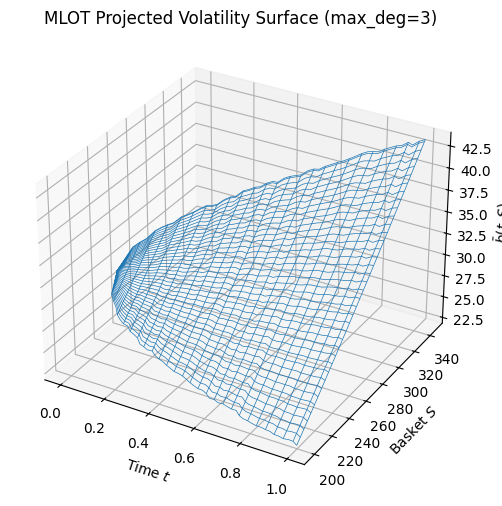

basket0 shape: (10000, 64)
len(t_plot): 64


In [24]:
dt_plot = h0 * 2**(-max_deg)
N_t_plot = int(T / dt_plot)
t_plot = np.linspace(0, T, N_t_plot)
fig, ax = plot_local_volatility(
    b_bar=b_bar_ot,
    basket=basket0,
    t=t_plot,
    K=50,
    L=150,
    title=f"MLOT Projected Volatility Surface (max_deg={max_deg})",
    color="C0",
    save_path='MLOTsurfmd3.pdf',  # or e.g. "ML_VolSurf_maxdeg3.pdf"
)
plt.show()
print("basket0 shape:", basket0.shape)
print("len(t_plot):", len(t_plot))